In [1]:
import sys

sys.path.append("/Users/ikergg/Documents/Python learning/Proyectos/Empezando")

import os
from dotenv import load_dotenv

load_dotenv("/Users/ikergg/Documents/Python learning/Proyectos/Empezando/.env")
FRED_KEY = os.getenv("FRED_KEY")

import pandas as pd
import numpy as np
import scipy
import time
from datetime import datetime, timedelta
import requests
import matplotlib.pyplot as plt
import cvxpy as cp
import streamlit as st
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

load_dotenv()
ALPACA_KEY = os.getenv("ALPACA_KEY")
ALPACA_SECRET = os.getenv("ALPACA_SECRET")
client = StockHistoricalDataClient(ALPACA_KEY,  ALPACA_SECRET)

In [64]:
def get_returns_cvar(symbol : str, START_DATE : str = "2016-01-01" ) -> pd.Series:
    "Download the rickers data"
    
    try:
        END_DATE= datetime.now()
        
        params = StockBarsRequest(
            symbol_or_symbols= symbol,
            timeframe=TimeFrame.Day,
            start=START_DATE,
            end=END_DATE,
            feed="iex",
            adjustment='all'
        )

        bars = client.get_stock_bars(params)
        df = bars.df.reset_index()
        
        if "symbol" in df.columns:
            df = df[df["symbol"]== symbol]
        
        df = bars.df.reset_index()
        df = df.set_index("timestamp")
        df["returns"] = np.log(df["close"] / df["close"].shift(1))
        
        return df["returns"].dropna()
       
    except:
        return

In [65]:
symbols= ["AAPL", "MSFT", "NVDA", "AMZN", "TSLA", "GOOGL", "META", "JPM", "XOM", "NFLX"]


data = {s: get_returns_cvar(s) for s in symbols}
df = pd.DataFrame(data)


,AAPL,MSFT,NVDA,AMZN,TSLA,GOOGL,META,JPM,XOM,NFLX
timestamp,,,,,,,,,,
2020-07-28 04:00:00+00:00,-0.016562,-0.008326,-0.019437,-0.018297,-0.041900,-0.016222,-0.015781,0.005016,-0.012328,-0.016056
2020-07-29 04:00:00+00:00,0.018301,0.009870,0.024238,0.011401,0.013396,0.012654,0.014098,0.023314,0.011452,-0.007403
2020-07-30 04:00:00+00:00,0.012732,-0.001441,0.012375,0.005455,-0.007835,0.008567,0.006074,-0.027971,-0.050909,0.002062
2020-07-31 04:00:00+00:00,0.099910,0.005546,-0.000947,0.036365,-0.038338,-0.032138,0.077920,-0.004438,0.004903,0.006774
2020-08-03 04:00:00+00:00,0.022829,0.055094,0.038091,-0.016442,0.036723,-0.003530,-0.007977,-0.004337,0.004575,0.019249
...,...,...,...,...,...,...,...,...,...,...
2026-04-17 04:00:00+00:00,0.025792,0.006241,0.017053,0.003139,0.030100,0.016882,0.016978,0.001355,-0.036175,-0.101993
2026-04-20 04:00:00+00:00,0.010511,-0.011036,0.002229,-0.008620,-0.020756,-0.012457,-0.025807,0.021903,0.007991,-0.025614
2026-04-21 04:00:00+00:00,-0.025594,0.014060,-0.011445,0.006082,-0.015667,-0.015409,-0.003329,-0.013014,0.004730,-0.023746


In [4]:
def cvar_efficient_frontier(df : pd.DataFrame, alpha : float = 0.05, n_points : int = 50 ) -> pd.DataFrame:
    "loop through min to max posible points to get the frontier"
    
    R = df.dropna().values
    T, N = R.shape

    mean_return = R.mean(axis = 0)
    min_return = mean_return.min()
    max_return = mean_return.max()
    targets = np.linspace(min_return, max_return, n_points)
    
    frontier = []
    
    for target in targets:
        
        w = cp.Variable(N)
        zeta = cp.Variable()
        u = cp.Variable(T)

        portfolio_losses = -R @ w
        cvar = zeta + (1 / (alpha * T)) * cp.sum(u)

        constraints = [
            u >= portfolio_losses - zeta,
            u >= 0,
            cp.sum(w) == 1,
            w >= 0,
            (R @ w) @ np.ones(T) / T >= target,
        ]
        
        prob = cp.Problem(cp.Minimize(cvar), constraints)
        prob.solve()
        
        portfolio_returns = R @ w.value
        sharpe = (portfolio_returns.mean() * 252 - 0.035) / (portfolio_returns.std() * np.sqrt(252))
        
        if prob.status in ["optimal", "optimal_inaccurate"]:
            frontier.append({
                "target_return": target,
                "cvar": cvar.value,
                "weights": pd.Series(w.value, index=df.columns),
                "annual_return": portfolio_returns.mean() * 252,
                "annual_std": portfolio_returns.std() * np.sqrt(252),
                "sharpe": sharpe,
            })
            
    return pd.DataFrame([{
        "target_return": f["target_return"],
        "cvar": f["cvar"],
        "annual_return": f["annual_return"],
        "annual_std": f["annual_std"],
        "sharpe": f["sharpe"],
    } for f in frontier]), frontier

In [5]:
frontier_df,frontier_full=  cvar_efficient_frontier(df)

In [6]:
def cvar_weights(frontier_df: pd.DataFrame, frontier_full : pd.DataFrame) -> pd.DataFrame:
    "gets all the weights at each return "
    
    weights_df = pd.DataFrame(
        [f["weights"] for f in frontier_full],
        index=frontier_df["target_return"]
    )

    weights_df = weights_df.clip(lower=0)
    weights_df = weights_df.div(weights_df.sum(axis=1), axis=0)
    
    return weights_df

In [7]:
weights= cvar_weights(frontier_df, frontier_full)

In [8]:
# Assuming 'all_returns' is a DataFrame where columns are symbols
lookback = 252
step = 5  # Weekly rebalance
num_assets = len(symbols)
equal_weights = np.ones(num_assets) / num_assets
results = []

def adjusting_cvar_backtest(returns: pd.DataFrame, lookback: int = 252, steps: int = 5) -> pd.Series:
    "Get returns of a portfolio that adjusts to the highest sharpe ratio portfolio based on a CVaR analysis"
    
    dates = []
    daily_returns = []

    for i in range(lookback, len(returns) - steps, steps):
        
        window_data = returns.iloc[i - lookback:i]
        next_period = returns.iloc[i:i + steps]

        df_frontier, frontier_details = cvar_efficient_frontier(window_data)
        
        best_idx = df_frontier['sharpe'].idxmax()
        optimal_weights = frontier_details[best_idx]['weights'].values

        period_returns = (next_period @ optimal_weights).tolist()
        
        dates.extend(next_period.index.tolist())
        daily_returns.extend(period_returns)

    return pd.Series(daily_returns, index=dates)


def static_cvar_backtest(returns: pd.DataFrame, lookback: int = 252, steps: int = 5) -> pd.Series:
    "Get the returns of a portfolio investing equal weights and not adjusting"
    
    num_assets = returns.shape[1]
    equal_weights = np.ones(num_assets) / num_assets
    
    dates = []
    daily_returns = []

    for i in range(lookback, len(returns) - steps, steps):
        
        next_period = returns.iloc[i:i + steps]
        period_returns = (next_period @ equal_weights).tolist()
        
        dates.extend(next_period.index.tolist())
        daily_returns.extend(period_returns)

    return pd.Series(daily_returns, index=dates)


In [40]:
spy_returns= get_returns_cvar("SPY")
spy_df = pd.DataFrame(spy_returns)

In [53]:
cvar_series = adjusting_cvar_backtest(df)
eq_series = static_cvar_backtest(df)
series_spy = static_cvar_backtest(spy_df)

cvar_cumulative = (1 + cvar_series).cumprod()
eq_cumulative = (1 + eq_series).cumprod()
cumulative_spy = (1 + series_spy).cumprod()

In [58]:
cumulative_spy= cumulative_spy[:-5]

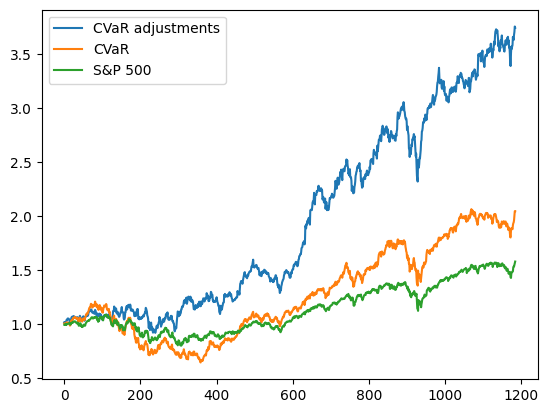

In [59]:

x = range(len(cvar_cumulative))  # or your own x values

plt.plot(x, cvar_cumulative, label="CVaR adjustments")
plt.plot(x, eq_cumulative, label="CVaR")
plt.plot(x, cumulative_spy, label="S&P 500")

plt.legend()
plt.show()


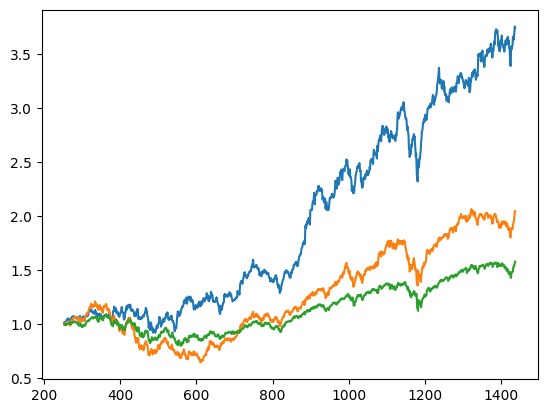

In [ ]:
combined_returns = pd.concat([cvar_series, eq_series, series_spy], axis=1, join="inner").dropna()

combined_cumulative = (1 + combined_returns).cumprod()

# 4. Plot
combined_cumulative.columns = ["CVaR adjusted", "CVaR", "S&P 500"]
plt.plot(combined_cumulative)

In [62]:
print(combined_cumulative)

      CVaR adjusted      CVaR   S&P 500
253        1.017742  1.007298  0.995440
254        1.015595  1.003826  0.995101
255        1.010907  0.995172  0.999255
256        1.020198  1.000255  0.994306
257        1.016740  0.999573  0.992295
...             ...       ...       ...
1433       3.633769  1.942774  1.536162
1434       3.682379  1.963025  1.534986
1435       3.709037  2.002453  1.549939
1436       3.758963  2.047936  1.568713
1437       3.746483  2.048003  1.580843

[1185 rows x 3 columns]
